# GBM Regularization Grid Search

Linear models on `fwd_ret_8h` produce weak positive validation IC. GBM tests
whether tree-based interactions can improve on that baseline without relying
on a large cross-section. With only 19 symbols, the leaf count and loss
function are both consequential regularization choices.

The grid covers 5 leaf-count profiles × 3 objectives (MSE, MAE, Huber) = 15
configurations. Cross-sectional IC is evaluated at checkpoints (every 50
iterations) to identify optimal stopping.

**Learning Objectives**:
- Test whether non-linear interactions improve on the weak-positive linear baseline
- Compare regularization profiles on walk-forward cross-validation
- Track IC learning curves to find optimal stopping per config
- Generate backtesting-ready predictions from the best configuration

**Book Reference**: Chapter 12, Section 12.2 (GBM Libraries)

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb),
[`04_model_based_features`](04_model_based_features.ipynb), and [`06_linear`](06_linear.ipynb)

In [1]:
"""GBM grid search across regularization profiles and loss functions."""

import warnings
from datetime import UTC, datetime

# Load PyTorch before ml4t.diagnostic so its bundled CUDA runtime wins symbol resolution.
import torch  # noqa: F401

# isort: split
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
import yaml
from ml4t.diagnostic.metrics import cross_sectional_ic

import utils.style as style
from case_studies.utils.gbm import (
    prepare_gbm_folds,
    register_gbm_result,
    resolve_gbm_device,
    train_gbm_config,
)
from case_studies.utils.registry import (
    build_training_spec,
    get_training_dir,
    load_prediction_metrics,
    load_prediction_sets,
    modeling_input_fingerprint,
    read_predictions,
    training_hash_from_spec,
    training_run_status,
)
from utils.cv_splits import load_evaluation_config
from utils.modeling import load_configs, load_modeling_dataset
from utils.paths import get_case_study_dir

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "crypto_perps_funding"
PRIMARY_LABEL = ""
MAX_SYMBOLS = 0
MAX_FOLDS = 0
FORCE_RETRAIN = False  # Set True to retrain configs that already have complete hashes
PREDICTION_SPLIT = "validation"
TRAIN_SAMPLE_FRAC = 1.0  # <1.0 subsamples training rows; validation is never sampled
TRAIN_DEVICE = ""  # Blank uses setup.yaml; CUDA requires a CUDA-enabled LightGBM build
MAX_BIN = 63

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

if not PRIMARY_LABEL:
    PRIMARY_LABEL = setup["labels"]["primary"]

_configured_device = str(setup.get("modeling", {}).get("gbm", {}).get("device", "cpu"))
TRAIN_DEVICE = resolve_gbm_device(TRAIN_DEVICE, _configured_device)
print(f"Case study: {CASE_STUDY_ID} | Device: {TRAIN_DEVICE} | max_bin: {MAX_BIN}")

Case study: crypto_perps_funding | Device: cpu | max_bin: 63


## 1. Load Data and Model Configs

GBM configs are defined in `config/training/{label}.yaml` under the `gbm:` key.
Each config references a preset in `config/lgb/` with the complete
LightGBM parameter set. To modify the grid, edit the label config file.

In [4]:
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)

dataset = mds.dataset
feature_names = mds.feature_names
label_col = mds.label_col
date_col = mds.date_col
entity_col = mds.entity_cols[0] if mds.entity_cols else "symbol"
splits = mds.splits[: MAX_FOLDS or None]
holdout_start = datetime.fromisoformat(load_evaluation_config(CASE_STUDY_ID)["holdout_start"])
holdout_start = holdout_start.replace(tzinfo=UTC)
label_horizon = pd.Timedelta(mds.label_buffer)
assert all(split["val_end"] + label_horizon < holdout_start for split in splits)
INPUT_FINGERPRINT = modeling_input_fingerprint(
    CASE_DIR,
    PRIMARY_LABEL,
    mds.splits,
    feature_names,
    MAX_SYMBOLS,
)
IDENTITY_PARAMS = {
    "device": TRAIN_DEVICE,
    "input_fingerprint": INPUT_FINGERPRINT,
    "max_symbols": MAX_SYMBOLS,
}

print(f"Dataset: {len(dataset):,} rows × {len(feature_names)} features")
print(f"Label: {label_col} | Task: {mds.task_type} | Folds: {len(splits)}")
print(f"Input lineage: {INPUT_FINGERPRINT[:12]}")

Dataset: 99,851 rows × 44 features
Label: fwd_ret_8h | Task: regression | Folds: 2
Input lineage: b8cd50089c07


In [5]:
configs = load_configs(CASE_STUDY_ID, PRIMARY_LABEL, family="gbm")

print(f"\n{len(configs)} configs × {len(splits)} folds\n")
for cfg in configs:
    leaves = cfg["params"].get("num_leaves", 31)
    obj = cfg["params"].get("objective", "regression")
    n_trees = cfg.get("max_iterations", 500)
    print(f"  {cfg['config_name']:25s}  leaves={leaves:3d}  obj={obj}  trees={n_trees}")


15 configs × 2 folds

  default_mse                leaves= 31  obj=regression  trees=500
  default_mae                leaves= 31  obj=regression_l1  trees=500
  default_huber              leaves= 31  obj=huber  trees=500
  leaves_7_mse               leaves=  7  obj=regression  trees=500
  leaves_7_mae               leaves=  7  obj=regression_l1  trees=500
  leaves_7_huber             leaves=  7  obj=huber  trees=500
  leaves_15_mse              leaves= 15  obj=regression  trees=500
  leaves_15_mae              leaves= 15  obj=regression_l1  trees=500
  leaves_15_huber            leaves= 15  obj=huber  trees=500
  leaves_31_mse              leaves= 31  obj=regression  trees=500
  leaves_31_mae              leaves= 31  obj=regression_l1  trees=500
  leaves_31_huber            leaves= 31  obj=huber  trees=500
  leaves_63_mse              leaves= 63  obj=regression  trees=500
  leaves_63_mae              leaves= 63  obj=regression_l1  trees=500
  leaves_63_huber            leaves= 63  obj

## 2. Prepare CV Folds

GBM folds use float32 (LightGBM native precision) and skip
imputation/scaling because gradient boosting handles missing values natively.

In [6]:
dataset_pd = dataset.to_pandas()
fold_data = prepare_gbm_folds(
    dataset_pd,
    splits,
    feature_names,
    label_col,
    date_col,
    entity_col,
    task_type=mds.task_type,
    class_values=mds.class_values,
    temporal_by_fold=mds.temporal_by_fold,
    temporal_keys=mds.temporal_keys,
    temporal_feature_names=mds.temporal_feature_names,
    train_sample_frac=TRAIN_SAMPLE_FRAC,
)

for f in fold_data:
    print(f"  Fold {f['fold']}: train={f['n_train']:,}  val={f['n_val']:,}")

  Fold 0: train=31,402  val=18,542
  Fold 1: train=23,681  val=16,738


### Canonical checkpoint scoring

A checkpoint is comparable only when it covers the same validation timestamps
without null predictions. We pool predictions from all walk-forward folds,
compute rank IC within each decision timestamp, and then average over time.
Averaging one aggregate IC per fold would give the folds equal weight even when
they contain different numbers of decision timestamps.

In [7]:
def _checkpoint_summary(predictions: list[dict], config_name: str) -> list[dict]:
    """Score each checkpoint on pooled decision-time validation IC."""
    rows = []
    checkpoints = sorted({int(p["n_trees"]) for p in predictions})
    for checkpoint in checkpoints:
        parts = []
        for pred in predictions:
            if int(pred["n_trees"]) != checkpoint:
                continue
            parts.append(
                pl.DataFrame(
                    {
                        date_col: pred["dates"],
                        entity_col: pred["entities"],
                        "actual": pred["y_true"],
                        "prediction": pred["y_pred"],
                    }
                )
            )
        checkpoint_predictions = pl.concat(parts)
        ic_stats = cross_sectional_ic(
            checkpoint_predictions,
            checkpoint_predictions,
            pred_col="prediction",
            ret_col="actual",
            date_col=date_col,
            entity_col=entity_col,
            min_obs=5,
        )
        rows.append(
            {
                "config": config_name,
                "iteration": checkpoint,
                "ic_mean": float(ic_stats["ic_mean"]),
                "ic_std": float(ic_stats["ic_std"]),
                "ic_n_days": int(ic_stats["n_periods"]),
                "n_obs": checkpoint_predictions.height,
                "n_null": int(
                    checkpoint_predictions["prediction"].null_count()
                    + checkpoint_predictions["prediction"].is_nan().sum()
                ),
            }
        )
    return rows


def _canonicalize_result(result: dict) -> dict:
    """Replace fold-mean checkpoint scores with pooled decision-time scores."""
    curves = _checkpoint_summary(result["predictions"], result["config_name"])
    full_days = max(row["ic_n_days"] for row in curves)
    eligible = [row for row in curves if row["n_null"] == 0 and row["ic_n_days"] == full_days]
    if not eligible:
        raise RuntimeError(f"No complete checkpoint for {result['config_name']}")
    best_curve = max(eligible, key=lambda row: row["ic_mean"])
    best_iter = int(best_curve["iteration"])

    fold_metrics = []
    n_train = {fold["fold"]: fold["n_train"] for fold in fold_data}
    for pred in result["predictions"]:
        if int(pred["n_trees"]) != best_iter:
            continue
        fold_frame = pl.DataFrame(
            {
                date_col: pred["dates"],
                entity_col: pred["entities"],
                "actual": pred["y_true"],
                "prediction": pred["y_pred"],
            }
        )
        fold_ic = cross_sectional_ic(
            fold_frame,
            fold_frame,
            pred_col="prediction",
            ret_col="actual",
            date_col=date_col,
            entity_col=entity_col,
            min_obs=5,
        )
        fold_metrics.append(
            {
                "fold_id": pred["fold"],
                "ic_mean": float(fold_ic["ic_mean"]),
                "n_train": n_train[pred["fold"]],
                "n_test": len(pred["y_true"]),
            }
        )

    result.update(
        {
            "best_iter": best_iter,
            "best_ic": float(best_curve["ic_mean"]),
            "best_ic_std": float(best_curve["ic_std"]),
            "ic_n_days": int(best_curve["ic_n_days"]),
            "n_null": int(best_curve["n_null"]),
            "learning_curves": curves,
            "fold_metrics": fold_metrics,
        }
    )
    return result

## 3. Train All Configs

For each config, train one LightGBM model per fold to `max_iterations` trees.
Cross-sectional IC is evaluated at checkpoints (every 50 iterations). On a
complete content-matched registry, this section reads the registered physical
prediction sets and performs no training or registry writes. Boosters are not
replayed on the cached path. A fresh registry trains on fail-closed CUDA and
registers the canonically scored result.

In [8]:
results = []
for cfg in configs:
    # Pre-compute registry training dir so boosters go directly there
    spec = build_training_spec(
        cfg["family"],
        cfg["config_name"],
        label_col,
        n_folds=len(fold_data),
        max_bin=MAX_BIN,
        checkpoint_interval=cfg.get("checkpoint_interval", 50),
        train_sample_frac=TRAIN_SAMPLE_FRAC,
        extra_params=IDENTITY_PARAMS,
    )
    train_dir = get_training_dir(CASE_STUDY_ID, spec)

    # Skip if this config's hash is already complete (unless FORCE_RETRAIN)
    _status = training_run_status(CASE_STUDY_ID, spec)
    _training_hash = training_hash_from_spec(spec)
    _split_rows = load_prediction_sets(
        CASE_STUDY_ID,
        training_hash=_training_hash,
        split=PREDICTION_SPLIT,
    )
    _split_complete = not _split_rows.is_empty()
    if _status.complete and _split_complete and not FORCE_RETRAIN:
        # The registered prediction set is the read-only cache artifact. Its
        # training hash already binds the current feature lineage and CUDA device.
        _pred_hash = _split_rows["prediction_hash"][0]
        _metrics = load_prediction_metrics(CASE_STUDY_ID, prediction_hash=_pred_hash)
        _cached_ic = (
            float(_metrics["ic_mean_daily"][0]) if not _metrics.is_empty() else float("nan")
        )
        _cached_ic_std = (
            float(_metrics["ic_std_daily"][0]) if not _metrics.is_empty() else float("nan")
        )
        _cached_days = int(_metrics["ic_n_days"][0]) if not _metrics.is_empty() else 0
        _cached_predictions = read_predictions(CASE_STUDY_ID, _pred_hash)
        _cached_nulls = _cached_predictions.select(
            pl.col("y_score").is_null().sum() + pl.col("y_score").is_nan().sum()
        ).item()
        _curve_path = train_dir / "learning_curves.parquet"
        _cached_curves = pl.read_parquet(_curve_path).to_dicts() if _curve_path.is_file() else []
        _complete_curves = [
            row
            for row in _cached_curves
            if row.get("n_null") == 0 and row.get("ic_n_days") == _cached_days
        ]
        _cached_best_iter = (
            int(max(_complete_curves, key=lambda row: row["ic_mean"])["iteration"])
            if _complete_curves
            else None
        )
        result = {
            "config_name": cfg["config_name"],
            "best_iter": _cached_best_iter,
            "best_ic": _cached_ic,
            "best_ic_std": _cached_ic_std,
            "ic_n_days": _cached_days,
            "n_obs": _cached_predictions.height,
            "n_null": int(_cached_nulls),
            "elapsed_s": 0.0,
            "learning_curves": _cached_curves,
            "cached": True,
        }
        print(
            f"  {cfg['config_name']:25s}  cached IC={_cached_ic:+.4f}  "
            f"n={_cached_days:,} dates / {_cached_predictions.height:,} rows  "
            f"({_status.summary()})"
        )
        results.append(result)
        continue
    if _status.complete and not _split_complete:
        print(f"  {cfg['config_name']:25s}  RETRAIN - missing {PREDICTION_SPLIT} predictions")
    elif _status.partial:
        print(f"  {cfg['config_name']:25s}  RETRAIN - partial state: {_status.summary()}")

    result = train_gbm_config(
        cfg,
        fold_data,
        feature_names=feature_names,
        device=TRAIN_DEVICE,
        max_bin=MAX_BIN,
        entity_col=entity_col,
        date_col=date_col,
        task_type=mds.task_type,
        class_values=mds.class_values,
        save_dir=train_dir,
    )
    result = _canonicalize_result(result)
    results.append(result)
    print(
        f"  {result['config_name']:25s}  iter={result['best_iter']:4d}  "
        f"IC={result['best_ic']:+.4f}  ({result['elapsed_s']:.0f}s)"
    )

    # Register immediately after training - incremental save protects against
    # interruption losing work on large sweeps.
    register_gbm_result(
        CASE_STUDY_ID,
        result,
        cfg,
        label_col,
        n_folds=len(fold_data),
        max_bin=MAX_BIN,
        entry_point="07_gbm",
        date_col=date_col,
        entity_col=entity_col,
        train_sample_frac=TRAIN_SAMPLE_FRAC,
        prediction_split=PREDICTION_SPLIT,
        extra_params=IDENTITY_PARAMS,
    )

      fold 0: training n_train=31,402 n_val=18,542 trees=500 num_leaves=? obj=regression


      fold 0: done in 0s


      fold 1: training n_train=23,681 n_val=16,738 trees=500 num_leaves=? obj=regression


      fold 1: done in 0s


  default_mse                iter=  50  IC=+0.0071  (1s)


...

      fold 0: training n_train=31,402 n_val=18,542 trees=500 num_leaves=63 obj=huber


      fold 0: done in 1s


      fold 1: training n_train=23,681 n_val=16,738 trees=500 num_leaves=63 obj=huber


      fold 1: done in 1s


  leaves_63_huber            iter= 100  IC=+0.0189  (2s)


## 4. Grid Results

Configs are ranked only among prediction sets with complete validation coverage.
On the cached path, the ranking reproduces the content-matched registry from
physical predictions. On a fresh training path, the same table ranks newly fitted CUDA
models using the canonical decision-time statistic.

In [9]:
results.sort(
    key=lambda row: row["best_ic"] if np.isfinite(row["best_ic"]) else -np.inf, reverse=True
)
_finite_days = [row["ic_n_days"] for row in results if np.isfinite(row["ic_n_days"])]
_full_days = max(_finite_days) if _finite_days else None
full_cov = [
    row
    for row in results
    if row["n_null"] == 0 and (_full_days is None or row["ic_n_days"] == _full_days)
]
partial_cov = [row for row in results if row not in full_cov]
best = full_cov[0] if full_cov else None
cached_mode = bool(results) and all(row.get("cached", False) for row in results)

if cached_mode:
    print(f"{'Config':25s}  {'IC':>8s}  {'N Dates':>7s}  {'N Rows':>7s}")
    print("-" * 56)
    for row in full_cov:
        marker = " *" if row is best else ""
        print(
            f"  {row['config_name']:25s}  {row['best_ic']:+.4f}  "
            f"{row['ic_n_days']:7d}  {row['n_obs']:7d}{marker}"
        )
else:
    print(f"{'Config':25s}  {'Iter':>5s}  {'IC':>8s}  {'N Dates':>7s}")
    print("-" * 54)
    for row in full_cov:
        marker = " *" if row is best else ""
        print(
            f"  {row['config_name']:25s}  {row['best_iter']:5d}  "
            f"{row['best_ic']:+.4f}  {row['ic_n_days']:7d}{marker}"
        )

if partial_cov:
    print("\nPartial coverage (excluded from selection):")
    for row in partial_cov:
        print(
            f"  {row['config_name']:25s}  IC={row['best_ic']:+.4f}  "
            f"n_dates={row['ic_n_days']}  n_null={row['n_null']}"
        )

if best:
    mode = "Cached current registry" if cached_mode else "Current training run"
    print(f"\n{mode} leader: {best['config_name']} (IC={best['best_ic']:+.4f})")

Config                      Iter        IC  N Dates
------------------------------------------------------
  leaves_63_mae                150  +0.0290     2189 *
  leaves_31_mae                100  +0.0230     2189
  leaves_7_mae                 100  +0.0222     2189
  default_mae                   50  +0.0211     2189
  leaves_63_mse                 50  +0.0196     2189
  leaves_63_huber              100  +0.0189     2189
  leaves_15_mae                 50  +0.0185     2189
  leaves_31_huber              400  +0.0174     2189
  leaves_15_mse                450  +0.0145     2189
  leaves_15_huber              500  +0.0139     2189
  leaves_7_mse                 350  +0.0120     2189
  leaves_7_huber               350  +0.0102     2189
  leaves_31_mse                300  +0.0102     2189
  default_huber                300  +0.0074     2189
  default_mse                   50  +0.0071     2189

Current training run leader: leaves_63_mae (IC=+0.0290)


### Content-matched results define the current non-linear benchmark

The chart ranks only predictions whose hash binds the corrected current feature
lineage and CUDA execution contract. A cached replay reads those physical
predictions without loading boosters, fitting models, or writing the registry.

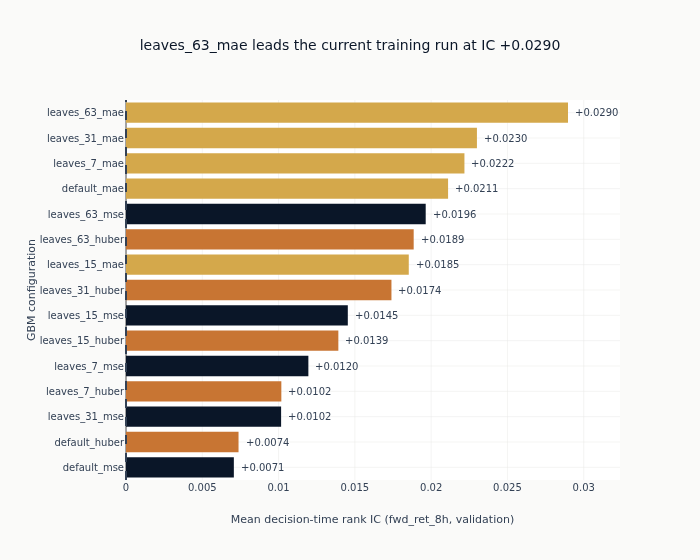

In [10]:
_LOSS_COLORS = {
    "mse": style.COLORS["blue"],
    "mae": style.COLORS["amber"],
    "huber": style.COLORS["copper"],
}


def _loss_of(config_name: str) -> str:
    return next((loss for loss in _LOSS_COLORS if config_name.endswith(loss)), "mse")


if full_cov:
    ranked = sorted(full_cov, key=lambda row: row["best_ic"])
    names = [row["config_name"] for row in ranked]
    values = [row["best_ic"] for row in ranked]
    colors = [_LOSS_COLORS[_loss_of(name)] for name in names]
    figure = go.Figure(
        go.Bar(
            x=values,
            y=names,
            orientation="h",
            marker_color=colors,
            name="Cached current registry" if cached_mode else "Current training run",
        )
    )
    for name, value in zip(names, values, strict=True):
        figure.add_annotation(
            x=value if value >= 0 else 0.0,
            y=name,
            text=f"{value:+.4f}",
            showarrow=False,
            xanchor="left",
            xshift=5,
            font=dict(size=10, color=style.COLORS["neutral"]),
        )
    figure.add_vline(x=0.0, line=dict(color=style.COLORS["neutral"], dash="dash"))
    figure.update_layout(
        template="ml4t",
        title=f"{best['config_name']} leads the {mode.lower()} at IC {best['best_ic']:+.4f}",
        xaxis_title=f"Mean decision-time rank IC ({label_col}, validation)",
        yaxis_title="GBM configuration",
        height=560,
        margin=dict(l=125, r=80),
        legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0),
    )
    figure.show()

## 5. Learning Curves

A fresh run scores every checkpoint over the same complete validation timestamps
with the same decision-time IC definition. The cached replay reloads the saved
curves without loading a booster or fitting a model.

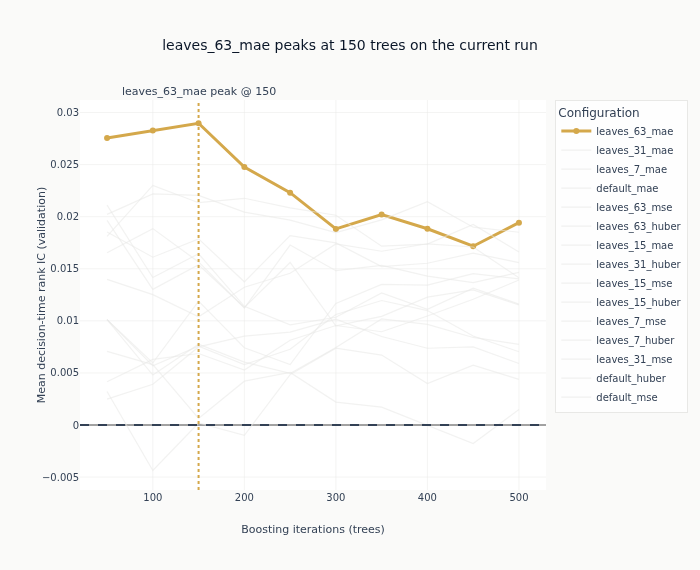

In [11]:
all_curves = pl.DataFrame([c for r in results for c in r["learning_curves"]])
if all_curves.height > 0:
    learning_figure = go.Figure()
    for row in results:
        config_curve = all_curves.filter(pl.col("config") == row["config_name"]).sort("iteration")
        is_leader = best is not None and row["config_name"] == best["config_name"]
        learning_figure.add_trace(
            go.Scatter(
                x=config_curve["iteration"].to_list(),
                y=config_curve["ic_mean"].to_list(),
                mode="lines+markers" if is_leader else "lines",
                name=row["config_name"],
                line=dict(
                    color=style.COLORS["amber"] if is_leader else style.COLORS["silver_muted"],
                    width=3 if is_leader else 1.2,
                ),
                marker=dict(size=6),
                opacity=1.0 if is_leader else 0.55,
            )
        )
    if best is not None:
        learning_figure.add_vline(
            x=best["best_iter"],
            line=dict(color=style.COLORS["amber"], dash="dot"),
            annotation_text=f"{best['config_name']} peak @ {best['best_iter']}",
            annotation_position="top",
        )
    learning_figure.add_hline(
        y=0.0,
        line=dict(color=style.COLORS["neutral"], dash="dash"),
    )
    learning_figure.update_layout(
        template="ml4t",
        title=(
            "GBM checkpoint performance varies materially across the current grid"
            if cached_mode
            else f"{best['config_name']} peaks at {best['best_iter']} trees on the current run"
        ),
        xaxis_title="Boosting iterations (trees)",
        yaxis_title="Mean decision-time rank IC (validation)",
        height=570,
        legend=dict(title="Configuration", font=dict(size=10)),
    )
    learning_figure.show()

## 6. Registry Disposition

The default cached path is read-only. On a fresh output root, each CUDA-trained
configuration is registered immediately after canonical checkpoint scoring so
an interrupted sweep retains completed work.

In [12]:
if cached_mode:
    print(
        f"Read-only current registry reconstruction complete for {len(results)} configurations; "
        "no boosters replayed and no registry writes."
    )
else:
    print(
        f"Training and registration complete for {len(results)} configurations; "
        f"current-run leader={best['config_name']} at IC {best['best_ic']:+.4f}."
    )

Training and registration complete for 15 configurations; current-run leader=leaves_63_mae at IC +0.0290.


## 7. Key Takeaways

This grid compares loss and leaf-budget choices on the corrected 44-feature
lineage. The displayed leader comes from complete physical validation predictions
across both folds and all 2,183 decision timestamps.

A fail-closed CUDA retrain in a fresh output root measures the corrected
44-feature lineage. GPU floating-point scheduling can move the last decimals,
so the registry binds the build, device, and current input fingerprint rather
than claiming CPU/GPU bit parity. The separate `fwd_ret_24h` carrier used by
the shipped strategy is assessed at the case-study level, not inferred from
this primary 8-hour grid.

**Next**: [`08_tabular_dl`](08_tabular_dl.ipynb) tests whether a tabular neural
model improves on the same validation folds.